In [15]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import glob
import re

ACCEL_LOG_GLOB = "/users/zarand1a/accel-sim-framework/sim_run_12.8/*/NO_ARGS/QV100-Accelwattch_SASS_SIM/accelwattch_power_report.log"
SIM_LOG_GLOB = "/users/zarand1a/accel-sim-framework/sim_run_12.8/*/NO_ARGS/QV100-Accelwattch_SASS_SIM/*-NO_ARGS.*"
MEASURED_LOG_DIR = "/proj/threadtune-PG0/amir/power_logs/"

IDLE_POWER_W = 32.325223 
FREQ_MHZ = 1132

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.figsize": (14, 3.5), # Wide for 2-column paper
    "hatch.linewidth": 0.5,
    "figure.autolayout": True
})

In [16]:
raw_power_df = (
    pl.scan_csv(ACCEL_LOG_GLOB, has_header=False, separator="?", include_file_paths="path")
    .select(
        pl.col("path").str.extract(r"sim_run_12.8/([^/]*)/.*/accelwattch_power_report.log").alias("benchmark"),
        pl.col("column_1").alias("data")
    )
    .filter(pl.col("data").str.contains("gpu_tot_avg_power"))
    .with_columns(
        pl.col("data").str.extract(r"=\s*([\d\.]+)").cast(pl.Float64).alias("accel_power_W")
    )
    .group_by("benchmark")
    .agg(pl.col("accel_power_W").mean())
    .collect()
)

In [17]:
raw_cycles_df = (
    pl.scan_csv(SIM_LOG_GLOB, has_header=False, separator="&", include_file_paths="path")
    .select(
        pl.col("path").str.extract(r"sim_run_12.8/([^/]*)/.*").alias("benchmark"),
        pl.col("column_1").alias("data")
    )
    .filter(pl.col("data").str.contains("gpu_sim_cycle"))
    .with_columns(
        pl.col("data").str.extract(r"=\s*(\d+)").cast(pl.Int64).alias("cycles")
    )
    .group_by("benchmark")
    .agg(pl.col("cycles").max())
    .collect()
)

In [24]:
measure_df = (
    pl.scan_csv(f"{MEASURED_LOG_DIR}/*-power.0.csv", include_file_paths="path")
    .with_columns(
        pl.col("path").str.extract(r"/([^/]+)-power.0.csv").alias("benchmark"),
        pl.when(pl.col("benchmark").str.contains("-train"))
        .then(pl.col("benchmark"))
        .otherwise(pl.col("benchmark") + "-inference")
        .alias("benchmark_mapped")
    )
    .group_by("benchmark_mapped")
    .agg(
        # Power = Energy (mJ) / Time (ms) -> Watts
        power_w=(
            (pl.col("total_energy_millijoules").max() - pl.col("total_energy_millijoules").min()) /
            ((pl.col("timestamp_ns").max() - pl.col("timestamp_ns").min()) / 1e6) 
        ),
        # Time in microseconds for consistency with AccelSim units
        time_us = (pl.col("timestamp_ns").max() - pl.col("timestamp_ns").min()) / 1000
    )
    .collect()
    .rename({"power_w": "measured_power_W", "time_us": "measured_time_us"})
)

ColumnNotFoundError: unable to find column "benchmark"; valid columns: ["timestamp_ns", "total_energy_millijoules", "path"]

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'sink' <---
Csv SCAN [/proj/threadtune-PG0/amir/power_logs/bert-power.0.csv, ... 11 other sources]
PROJECT */3 COLUMNS
ESTIMATED ROWS: 1059

In [25]:
measure_df = measure_df.with_columns(
    pl.when(pl.col("benchmark").str.contains("-train"))
    .then(pl.col("benchmark"))
    .otherwise(pl.col("benchmark") + "-inference")
    .alias("benchmark_mapped")
)
measure_df

benchmark,measured_power_W,measured_time_us,benchmark_mapped
str,f64,f64,str
"""gpt2""",38.570944,2.2697e8,"""gpt2-inference"""
"""resnet50-train""",70.123221,4.1215e8,"""resnet50-train"""
"""gemma""",107.656783,2.0229e8,"""gemma-inference"""
"""gemma-train""",82.827927,2.0493e9,"""gemma-train"""
"""bloom-train""",129.951943,3.4904e8,"""bloom-train"""
…,…,…,…
"""resnet50""",54.032302,4.1120e8,"""resnet50-inference"""
"""bloom""",74.344924,1.5222e8,"""bloom-inference"""
"""deit""",54.731851,4.1999e8,"""deit-inference"""


In [27]:
accel_data = raw_power_df.join(raw_cycles_df, on="benchmark")
accel_data = accel_data.with_columns(
    (pl.col("cycles") / FREQ_MHZ).alias("accel_time_us") # Cycles to Time
    , pl.col("benchmark").alias("benchmark_mapped")
)

master_df = (
    accel_data
    .join(measure_df, left_on="benchmark_mapped", right_on="benchmark_mapped")
    .with_columns([
        pl.lit(IDLE_POWER_W).alias("idle_power_W"),
        
        # Derived Idle Time = Real Time - Sim Time
        (pl.col("measured_time_us") - pl.col("accel_time_us")).alias("derived_idle_time_us")
    ])
    .with_columns([
        # Duty Cycle = Active Sim Time / Total Measured Time
        (pl.col("accel_time_us") / pl.col("measured_time_us")).alias("duty_cycle_pct"),
        
        # Correction Formula: (P_active * T_active + P_idle * T_idle) / T_total
        (
            (pl.col("accel_power_W") * pl.col("accel_time_us") + 
             pl.col("idle_power_W") * pl.col("derived_idle_time_us")) / 
            pl.col("measured_time_us")
        ).alias("corrected_power_W")
    ])
    .sort("benchmark")
)

master_df.select("benchmark", "measured_time_us", "accel_time_us", "duty_cycle_pct", "corrected_power_W")

benchmark,measured_time_us,accel_time_us,duty_cycle_pct,corrected_power_W
str,f64,f64,f64,f64
"""bert-train""",5.3658e8,746.034452,0.000001,32.325318
"""bloom-train""",3.4904e8,3821.270318,0.000011,32.326035
"""deit-train""",4.5747e8,347.385159,7.5937e-7,32.325268
"""gemma-train""",2.0493e9,3862.238516,0.000002,32.325468
"""gpt2-train""",5.2817e8,1448.567138,0.000003,32.325425
"""resnet50-train""",4.1215e8,1012.570671,0.000002,32.325376


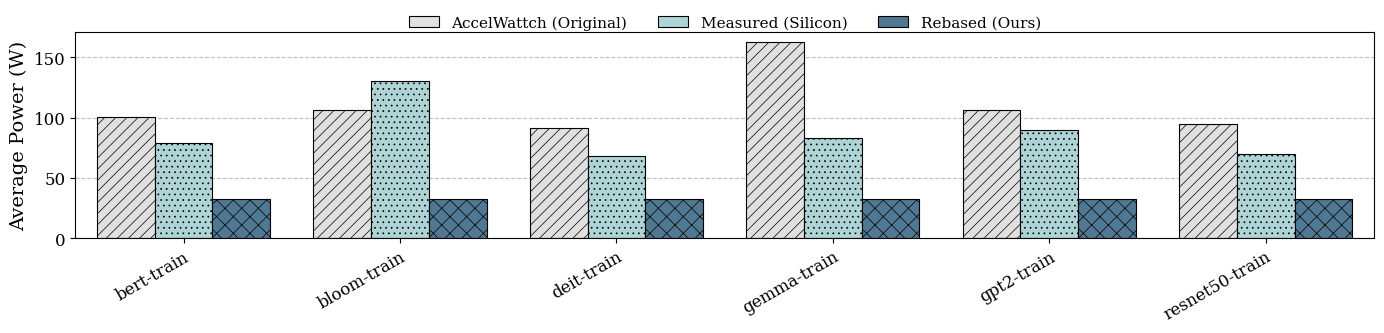


--- LaTeX Table: Execution Time Analysis ---
\begin{tabular}{lrrr}
\toprule
Model & Sim Time (s) & Real Time (s) & GPU Duty Cycle (%) \\
\midrule
bert-train & 0.000000 & 536.580000 & 0.000000 \\
bloom-train & 0.000000 & 349.040000 & 0.000000 \\
deit-train & 0.000000 & 457.470000 & 0.000000 \\
gemma-train & 0.000000 & 2049.290000 & 0.000000 \\
gpt2-train & 0.000000 & 528.170000 & 0.000000 \\
resnet50-train & 0.000000 & 412.150000 & 0.000000 \\
\bottomrule
\end{tabular}



In [28]:
plot_df = (
    master_df.select("benchmark", "accel_power_W", "measured_power_W", "corrected_power_W")
    .sort("benchmark")
    .rename({
        "accel_power_W": "AccelWattch (Original)",
        "measured_power_W": "Measured (Silicon)",
        "corrected_power_W": "Rebased (Ours)"
    })
    .unpivot(index="benchmark", value_name="power_W", variable_name="Type")
    .to_pandas()
)

fig, ax = plt.subplots()

# Define Colors: Light Grey, Teal/Cyan, Dark Slate Blue
colors = ["#e0e0e0", "#a8dadc", "#457b9d"] 

# Create Bar Plot
bar = sns.barplot(
    data=plot_df, 
    x="benchmark", 
    y="power_W", 
    hue="Type", 
    ax=ax, 
    palette=colors,
    edgecolor="black", 
    linewidth=0.8,
    width=0.8
)

# Define Hatches: Diagonal, Dots, Crosshatch
hatches = ['///', '...', 'xx'] 

# Apply hatches to bars
for i, container in enumerate(ax.containers):
    for patch in container:
        patch.set_hatch(hatches[i % len(hatches)])

# Axis Formatting
ax.grid(which='major', axis='y', linestyle='--', color='gray', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.set_xlabel("")
ax.set_ylabel("Average Power (W)")
plt.xticks(rotation=30, ha='right', rotation_mode="anchor")

# Legend
ax.legend(
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.15), # Put legend above plot
    ncol=3, 
    frameon=False,
    fontsize=11
)

# --- 5. GENERATE OUTPUTS ---

# Save Figure
plt.savefig("power_comparison_corrected.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Generate Time Discrepancy Table (Latex) for Section 2.2
# This proves that the "Idle Time" is actually massive framework overhead
latex_df = master_df.select(
    pl.col("benchmark").str.replace("_", "-").alias("Model"),
    (pl.col("accel_time_us") / 1e6).round(2).alias("Sim Time (s)"),
    (pl.col("measured_time_us") / 1e6).round(2).alias("Real Time (s)"),
    (pl.col("duty_cycle_pct") * 100).round(1).alias("GPU Duty Cycle (%)")
)
print("\n--- LaTeX Table: Execution Time Analysis ---")
print(latex_df.to_pandas().to_latex(index=False))